# Red Neuronal para Regresión — Dataset Salud Mental Adolescentes
**Variable dependiente:** `stress_level` (nivel de estrés, escala 1-10)

In [1]:
# =============================================================================
# RED NEURONAL PARA REGRESIÓN - Dataset Salud Mental Adolescentes
# Variable dependiente: stress_level (nivel de estrés, escala 1-10)
# =============================================================================
! pip install tensorflow scikit-learn openpyxl --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 50)
print("   RED NEURONAL - SALUD MENTAL ADOLESCENTES")
print("   Variable objetivo: stress_level (1-10)")
print("=" * 50)


   RED NEURONAL - SALUD MENTAL ADOLESCENTES
   Variable objetivo: stress_level (1-10)


In [2]:
# ================================
# 1. CARGA Y EXPLORACIÓN DE DATOS
# ================================
df = pd.read_excel("datosestresyansiedad.xlsx")

print(f"\n    Shape: {df.shape}  →  {df.shape[0]} adolescentes, {df.shape[1]} variables")
print(f"\n    Columnas: {list(df.columns)}")
print(f"\n    Primeras filas:")
print(df.head())



    Shape: (1200, 13)  →  1200 adolescentes, 13 variables

    Columnas: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'anxiety_level', 'addiction_level', 'depression_label', 'stress_level']

    Primeras filas:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2   

In [3]:
# Análisis Exploratorio (EDA)
print(f"\n    Estadísticas descriptivas (variables numéricas):")
print(df.describe().round(3))

print(f"\n    Valores nulos por columna:")
print(df.isnull().sum())

# Descripción de variables
descripcion = {
    "age"                       : "Edad del adolescente (13-19 años)",
    "gender"                    : "Género (male / female)",
    "daily_social_media_hours"  : "Horas diarias en redes sociales",
    "platform_usage"            : "Plataforma principal (Instagram / TikTok / Both)",
    "sleep_hours"               : "Horas de sueño por noche",
    "screen_time_before_sleep"  : "Tiempo de pantalla antes de dormir (horas)",
    "academic_performance"      : "Rendimiento académico (GPA estimado)",
    "physical_activity"         : "Actividad física diaria (horas)",
    "social_interaction_level"  : "Nivel de interacción social (low / medium / high)",
    "anxiety_level"             : "Nivel de ansiedad (escala 1-10)",
    "addiction_level"           : "Nivel de adicción a redes (escala 1-10)",
    "depression_label"          : "Etiqueta de depresión (0 = no, 1 = sí)",
    "stress_level"              : "*** VARIABLE OBJETIVO: Nivel de estrés (1-10) ***"
}
print("\n    Descripción de variables:")
for col, desc in descripcion.items():
    print(f"    {col:>30} → {desc}")



    Estadísticas descriptivas (variables numéricas):
            age  daily_social_media_hours  sleep_hours  \
count  1200.000                  1200.000     1200.000   
mean     15.928                     4.537        6.449   
std       2.022                     2.030        1.443   
min      13.000                     1.000        4.000   
25%      14.000                     2.800        5.200   
50%      16.000                     4.500        6.500   
75%      18.000                     6.300        7.600   
max      19.000                     8.000        9.000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count                  1200.000              1200.000           1200.000   
mean                      1.740                 2.990              1.015   
std                       0.717                 0.577              0.582   
min                       0.500                 2.000              0.000   
25%                       1.100            

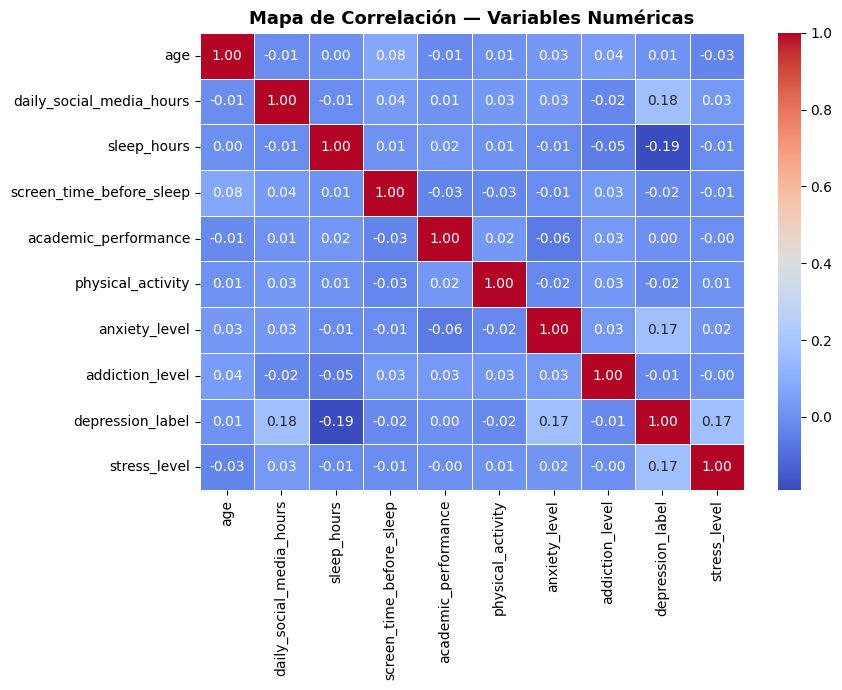

    Gráfico guardado: correlacion_estres.png


In [4]:
# Mapa de calor de correlación (solo variables numéricas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)

plt.title("Mapa de Correlación — Variables Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacion_estres.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Gráfico guardado: correlacion_estres.png")


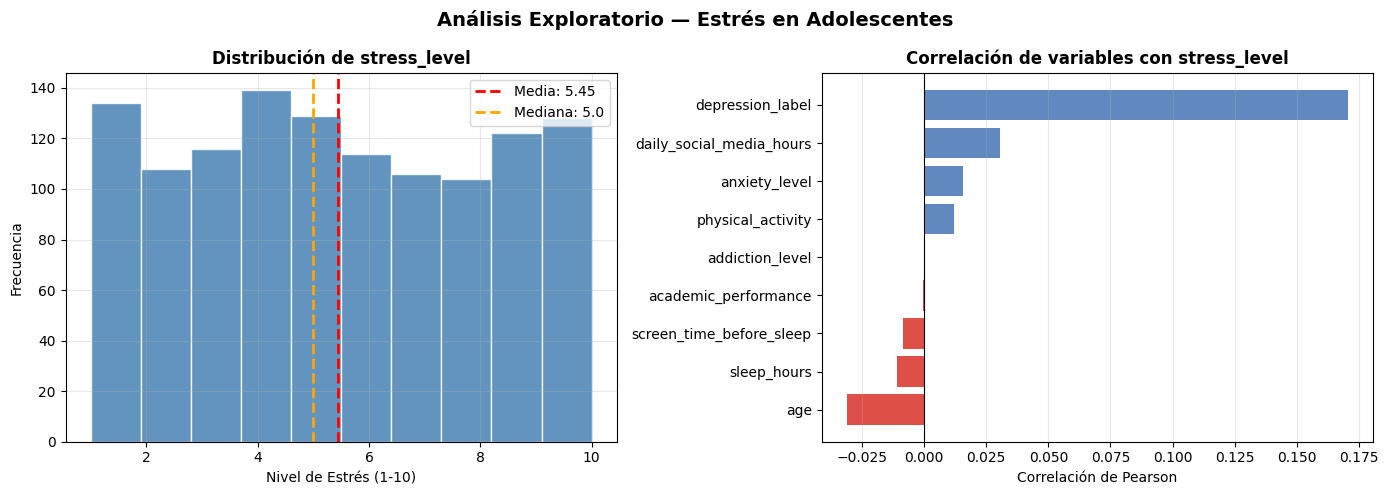

    Gráfico guardado: exploratorio_estres.png


In [5]:
# ================================
# 2. ANÁLISIS EXPLORATORIO RÁPIDO
# ================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis Exploratorio — Estrés en Adolescentes", fontsize=14, fontweight="bold")

# Distribución de stress_level
axes[0].hist(df["stress_level"], bins=10, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["stress_level"].mean(), color="red", linestyle="--",
                linewidth=2, label=f"Media: {df['stress_level'].mean():.2f}")
axes[0].axvline(df["stress_level"].median(), color="orange", linestyle="--",
                linewidth=2, label=f"Mediana: {df['stress_level'].median():.1f}")
axes[0].set_title("Distribución de stress_level", fontweight="bold")
axes[0].set_xlabel("Nivel de Estrés (1-10)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Correlación con stress_level (variables numéricas)
corr_stress = df[num_cols].corr()["stress_level"].drop("stress_level").sort_values()
colores = ["#d73027" if c < 0 else "#4575b4" for c in corr_stress]
axes[1].barh(corr_stress.index, corr_stress.values, color=colores, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de variables con stress_level", fontweight="bold")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("exploratorio_estres.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Gráfico guardado: exploratorio_estres.png")


In [6]:
# ========================
# 3. PREPARACIÓN DE DATOS
# ========================

# --- Codificación de variables categóricas ---
# gender: binary (male=0, female=1)
df["gender_enc"] = (df["gender"] == "female").astype(int)

# platform_usage: one-hot encoding
platform_dummies = pd.get_dummies(df["platform_usage"], prefix="platform", drop_first=False)
# Aseguramos columnas fijas aunque falte alguna categoría
for col in ["platform_Both", "platform_Instagram", "platform_TikTok"]:
    if col not in platform_dummies.columns:
        platform_dummies[col] = 0

# social_interaction_level: ordinal (low=0, medium=1, high=2)
social_map = {"low": 0, "medium": 1, "high": 2}
df["social_enc"] = df["social_interaction_level"].map(social_map)

# --- Construir DataFrame de features ---
feature_cols = [
    "age", "gender_enc", "daily_social_media_hours",
    "platform_Both", "platform_Instagram", "platform_TikTok",
    "sleep_hours", "screen_time_before_sleep", "academic_performance",
    "physical_activity", "social_enc",
    "anxiety_level", "addiction_level", "depression_label"
]

df_model = pd.concat([df, platform_dummies], axis=1)

TARGET = "stress_level"
X = df_model[feature_cols]
y = df_model[TARGET]

print(f"    Variables predictoras ({X.shape[1]}): {list(X.columns)}")
print(f"    Variable objetivo: {TARGET}")
print(f"    Rango de stress_level: [{y.min()}, {y.max()}]")
print(f"    Media: {y.mean():.2f} | Std: {y.std():.2f}")


    Variables predictoras (14): ['age', 'gender_enc', 'daily_social_media_hours', 'platform_Both', 'platform_Instagram', 'platform_TikTok', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_enc', 'anxiety_level', 'addiction_level', 'depression_label']
    Variable objetivo: stress_level
    Rango de stress_level: [1, 10]
    Media: 5.45 | Std: 2.90


In [7]:
# División en Entrenamiento / Validación / Prueba
# Split: 70% train | 15% val | 15% test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"\n    División del dataset:")
print(f"    ├── Train:      {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"    ├── Validación: {X_val.shape[0]} muestras ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"    └── Test:       {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.0f}%)")



    División del dataset:
    ├── Train:      840 muestras (70%)
    ├── Validación: 180 muestras (15%)
    └── Test:       180 muestras (15%)


In [8]:
# ====================================================
# 4. ESCALADO (fit SOLO en train → evita data leakage)
# ====================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print("    ✓ Escalado completado sin data leakage.")


    ✓ Escalado completado sin data leakage.


In [9]:
# ===================================
# 5. ARQUITECTURA DE LA RED NEURONAL
# ===================================

def build_model(input_dim, learning_rate=0.001):
    """
    Arquitectura para dataset de estrés (1200 muestras, 14 features):
    - Dataset mediano → capas moderadas con regularización
    - BatchNorm + Dropout para evitar overfitting
    - Salida lineal (regresión)
    """
    model = keras.Sequential([

        # Capa oculta 1: 128 neuronas
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
            input_shape=(input_dim,),
            name="oculta_1"
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Capa oculta 2: 64 neuronas
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
            name="oculta_2"
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Capa oculta 3: 32 neuronas
        layers.Dense(
            32,
            activation="relu",
            name="oculta_3"
        ),
        layers.Dropout(0.1),

        # Capa oculta 4: 16 neuronas
        layers.Dense(
            16,
            activation="relu",
            name="oculta_4"
        ),

        # Salida: 1 neurona, activación LINEAL → regresión
        layers.Dense(1, activation="linear", name="salida")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

input_dim = X_train_sc.shape[1]
model = build_model(input_dim)

print("\n    Resumen de la arquitectura:")
model.summary()



    Resumen de la arquitectura:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_4 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
# ==============
# 6. CALLBACKS
# ==============

# --- Early Stopping ---
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True,
    verbose=1
)
# --- ReduceLR on Plateau ---
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)
# --- Model Checkpoint ---
checkpoint = callbacks.ModelCheckpoint(
    filepath="mejor_modelo_estres.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

print("    ✓ EarlyStopping | ReduceLROnPlateau | ModelCheckpoint")
lista_callbacks = [early_stop, reduce_lr, checkpoint]


    ✓ EarlyStopping | ReduceLROnPlateau | ModelCheckpoint


In [11]:
# =================
# 7. ENTRENAMIENTO
# =================
print("\n[7] Entrenando red neuronal...")
print("    (Se detendrá si val_loss no mejora en 30 épocas)")

history = model.fit(
    X_train_sc, y_train_sc,
    validation_data=(X_val_sc, y_val_sc),
    epochs=300,
    batch_size=32,
    callbacks=lista_callbacks,
    verbose=1
)

epocas_reales = len(history.history["loss"])
print(f"\n    ✓ Entrenamiento finalizado en {epocas_reales} épocas.")



[7] Entrenando red neuronal...
    (Se detendrá si val_loss no mejora en 30 épocas)
Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 1.5318 - mae: 0.9803 - val_loss: 1.0278 - val_mae: 0.8324 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.1836 - mae: 0.8800 - val_loss: 1.0220 - val_mae: 0.8269 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.1481 - mae: 0.8647 - val_loss: 1.0109 - val_mae: 0.8207 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 1.1106 - mae: 0.8440 - val_loss: 1.0010 - val_mae: 0.8143 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.1109 - mae: 0.8423 - val_loss: 1.0020 - val_mae: 0.8152 - learning_rate: 0.0010
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0834 - mae: 0.8295 - val_loss: 1.0046 - val_mae: 0.8156 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.

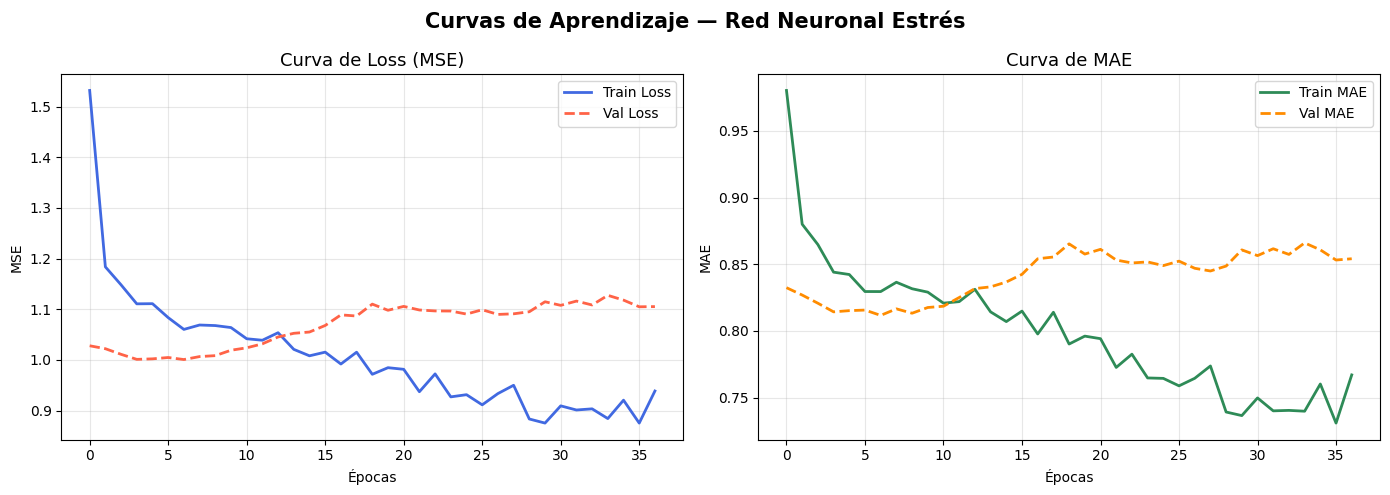

In [12]:
# Curvas de aprendizaje
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss (MSE) ---
axes[0].plot(hist_df["loss"],     label="Train Loss",  color="royalblue",  linewidth=2)
axes[0].plot(hist_df["val_loss"], label="Val Loss",    color="tomato",     linewidth=2, linestyle="--")
axes[0].set_title("Curva de Loss (MSE)", fontsize=13)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- MAE ---
axes[1].plot(hist_df["mae"],     label="Train MAE",  color="seagreen",   linewidth=2)
axes[1].plot(hist_df["val_mae"], label="Val MAE",    color="darkorange", linewidth=2, linestyle="--")
axes[1].set_title("Curva de MAE", fontsize=13)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizaje — Red Neuronal Estrés", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
# ======================
# 8. EVALUACIÓN EN TEST
# ======================

# Predicciones → desescalar
y_pred_sc = model.predict(X_test_sc, verbose=0)
y_pred    = scaler_y.inverse_transform(y_pred_sc).ravel()
y_real    = y_test.values

# Métricas
mse  = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_real, y_pred)
r2   = r2_score(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print("\n" + "=" * 50)
print("   MÉTRICAS EN CONJUNTO TEST")
print("=" * 50)
print(f"   MSE   : {mse:.4f}")
print(f"   RMSE  : {rmse:.4f}")
print(f"   MAE   : {mae:.4f}")
print(f"   MAPE  : {mape:.2f}%")
print(f"   R²    : {r2:.4f}  ({r2*100:.1f}% varianza explicada)")
print("=" * 50)
print(f"\n   Interpretación:")
print(f"   → El modelo se equivoca en promedio ±{mae:.2f} puntos de estrés")
print(f"   → Explica el {r2*100:.1f}% de la variabilidad del nivel de estrés")



   MÉTRICAS EN CONJUNTO TEST
   MSE   : 7.5787
   RMSE  : 2.7529
   MAE   : 2.3452
   MAPE  : 86.41%
   R²    : 0.0165  (1.6% varianza explicada)

   Interpretación:
   → El modelo se equivoca en promedio ±2.35 puntos de estrés
   → Explica el 1.6% de la variabilidad del nivel de estrés


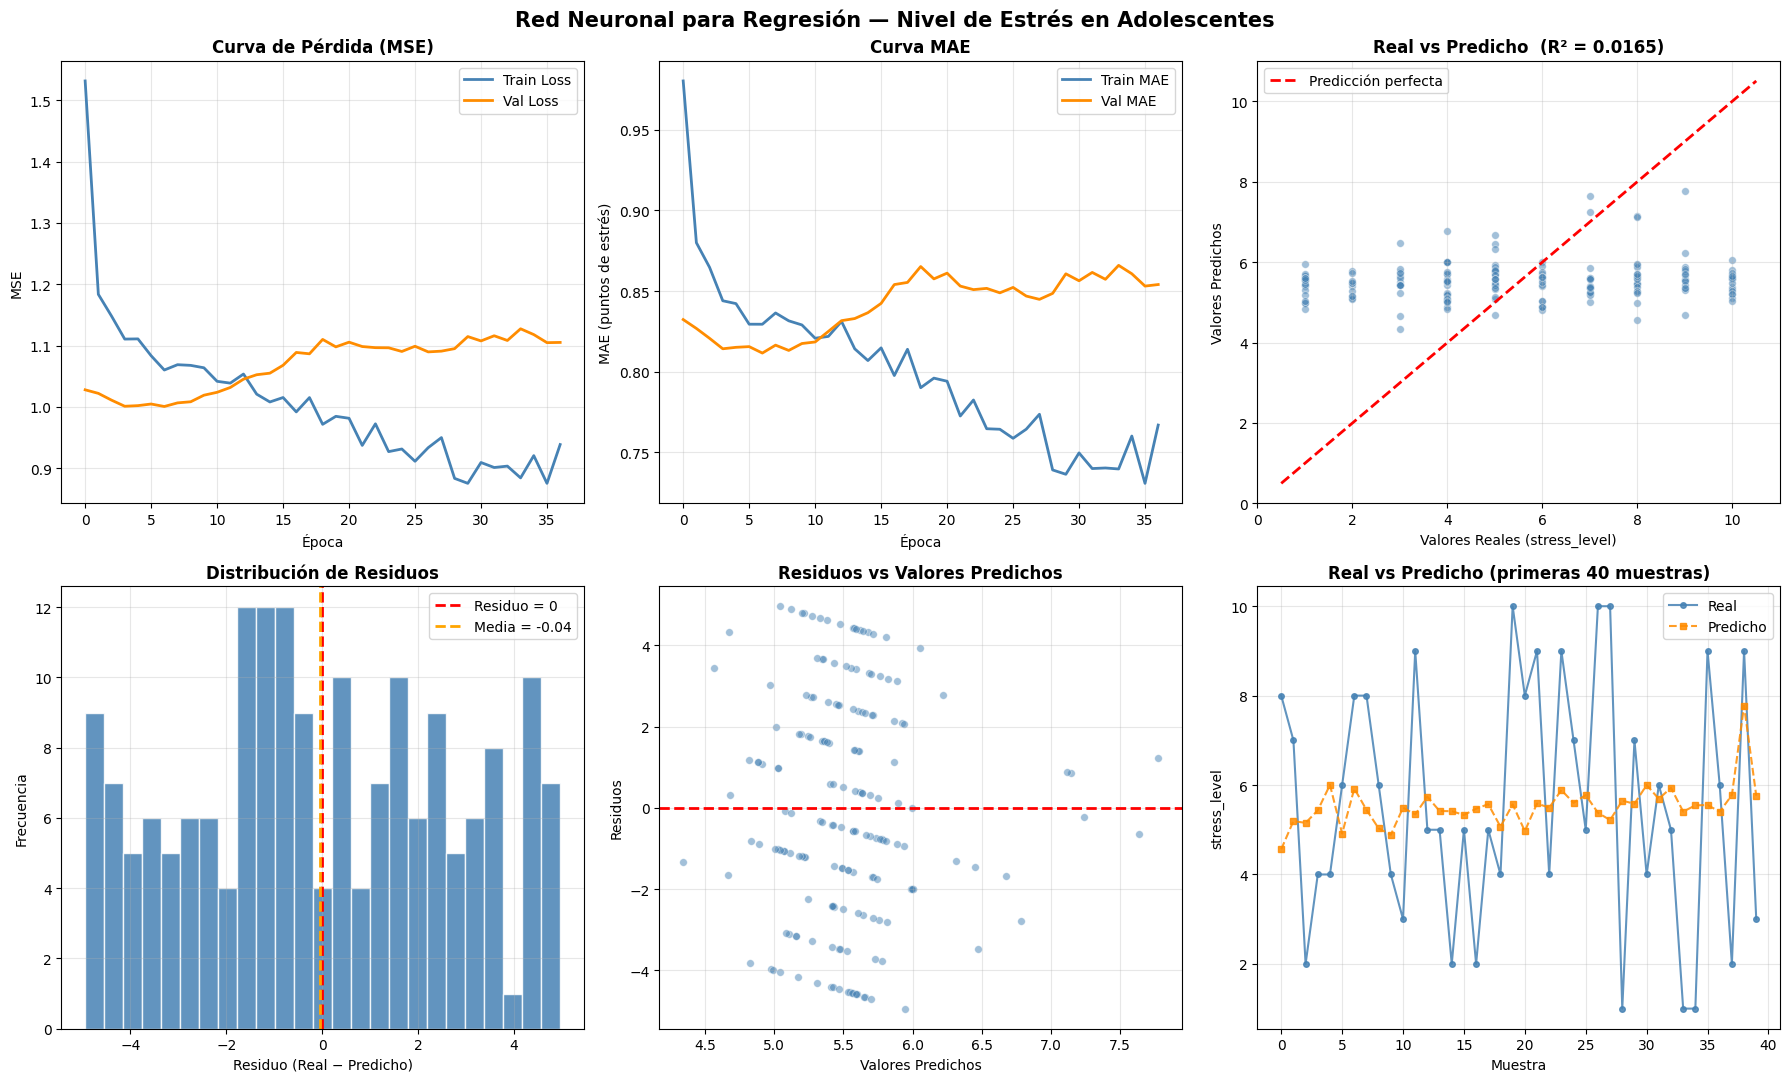

    ✓ Gráficos guardados: resultados_estres.png


In [14]:
# =============================
# 9. VISUALIZACIONES COMPLETAS
# =============================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Red Neuronal para Regresión — Nivel de Estrés en Adolescentes",
             fontsize=15, fontweight="bold")

# --- Plot 1: Curva de pérdida MSE ---
ax = axes[0, 0]
ax.plot(history.history["loss"],     label="Train Loss", color="steelblue",  linewidth=2)
ax.plot(history.history["val_loss"], label="Val Loss",   color="darkorange", linewidth=2)
ax.set_title("Curva de Pérdida (MSE)", fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Curva MAE ---
ax = axes[0, 1]
ax.plot(history.history["mae"],     label="Train MAE", color="steelblue",  linewidth=2)
ax.plot(history.history["val_mae"], label="Val MAE",   color="darkorange", linewidth=2)
ax.set_title("Curva MAE", fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("MAE (puntos de estrés)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Real vs Predicho ---
ax = axes[0, 2]
ax.scatter(y_real, y_pred, alpha=0.5, color="steelblue", s=30, edgecolors="white", linewidth=0.5)
lim_min = min(y_real.min(), y_pred.min()) - 0.5
lim_max = max(y_real.max(), y_pred.max()) + 0.5
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2, label="Predicción perfecta")
ax.set_title(f"Real vs Predicho  (R² = {r2:.4f})", fontweight="bold")
ax.set_xlabel("Valores Reales (stress_level)")
ax.set_ylabel("Valores Predichos")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Distribución de residuos ---
ax = axes[1, 0]
residuos = y_real - y_pred
ax.hist(residuos, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0,               color="red",    linestyle="--", linewidth=2, label="Residuo = 0")
ax.axvline(residuos.mean(), color="orange", linestyle="--", linewidth=2,
           label=f"Media = {residuos.mean():.2f}")
ax.set_title("Distribución de Residuos", fontweight="bold")
ax.set_xlabel("Residuo (Real − Predicho)")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 5: Residuos vs Predichos ---
ax = axes[1, 1]
ax.scatter(y_pred, residuos, alpha=0.5, color="steelblue", s=30, edgecolors="white", linewidth=0.5)
ax.axhline(0, color="red", linestyle="--", linewidth=2)
ax.set_title("Residuos vs Valores Predichos", fontweight="bold")
ax.set_xlabel("Valores Predichos")
ax.set_ylabel("Residuos")
ax.grid(True, alpha=0.3)

# --- Plot 6: Real vs Predicho (primeras 40 muestras) ---
ax = axes[1, 2]
n_show = 40
indices = np.arange(n_show)
ax.plot(indices, y_real[:n_show],  "o-",  color="steelblue",  linewidth=1.5,
        markersize=4, label="Real", alpha=0.85)
ax.plot(indices, y_pred[:n_show],  "s--", color="darkorange", linewidth=1.5,
        markersize=4, label="Predicho", alpha=0.85)
ax.set_title(f"Real vs Predicho (primeras {n_show} muestras)", fontweight="bold")
ax.set_xlabel("Muestra")
ax.set_ylabel("stress_level")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_estres.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráficos guardados: resultados_estres.png")



[10] Estimando importancia de variables (pesos capa 1)...


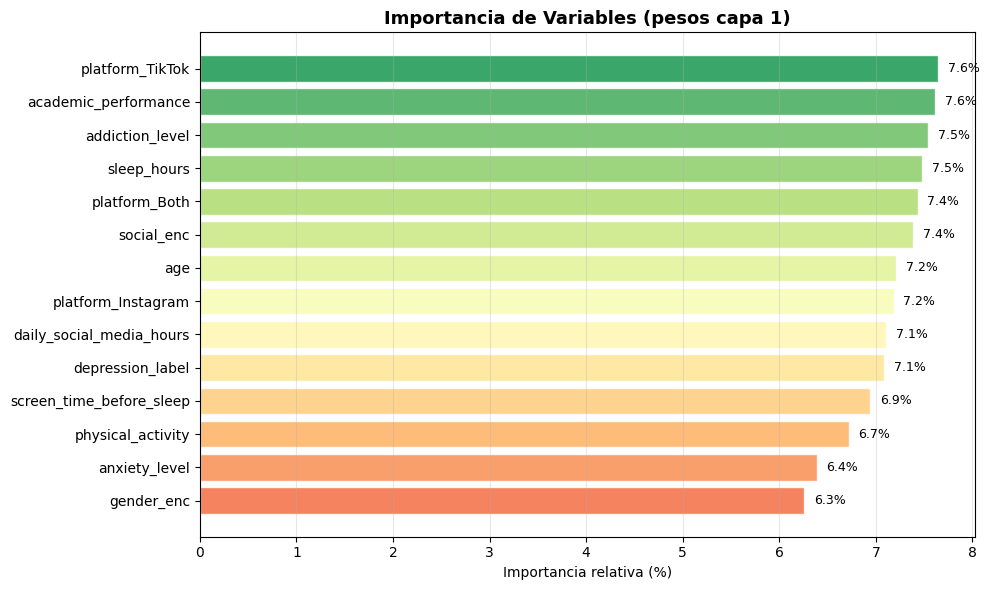

    ✓ Gráfico guardado: importancia_variables_estres.png

    Top 5 variables más influyentes:
                   platform_TikTok → 7.6%
              academic_performance → 7.6%
                   addiction_level → 7.5%
                       sleep_hours → 7.5%
                     platform_Both → 7.4%


In [15]:
# =============================================================================
# 10. IMPORTANCIA DE VARIABLES (por pesos de la primera capa)
# =============================================================================
print("\n[10] Estimando importancia de variables (pesos capa 1)...")

pesos_capa1    = np.abs(model.get_layer("oculta_1").get_weights()[0])
importancia    = pesos_capa1.mean(axis=1)
importancia_norm = importancia / importancia.sum() * 100

df_importancia = pd.DataFrame({
    "Variable"   : list(X.columns),
    "Importancia": importancia_norm
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_importancia)))
bars = ax.barh(df_importancia["Variable"], df_importancia["Importancia"],
               color=colores_imp, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, df_importancia["Importancia"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("Importancia de Variables (pesos capa 1)", fontweight="bold", fontsize=13)
ax.set_xlabel("Importancia relativa (%)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("importancia_variables_estres.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráfico guardado: importancia_variables_estres.png")

print("\n    Top 5 variables más influyentes:")
top5 = df_importancia.sort_values("Importancia", ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"    {row['Variable']:>30} → {row['Importancia']:.1f}%")



[11] Calculando Permutation Importance...

📊 Caída en R² al permutar cada variable:
physical_activity           0.0189
social_enc                  0.0157
sleep_hours                 0.0141
age                         0.0104
depression_label            0.0089
screen_time_before_sleep    0.0068
gender_enc                  0.0063
academic_performance        0.0056
anxiety_level               0.0019
daily_social_media_hours    0.0015
platform_Both              -0.0006
addiction_level            -0.0061
platform_TikTok            -0.0148
platform_Instagram         -0.0262
dtype: float64


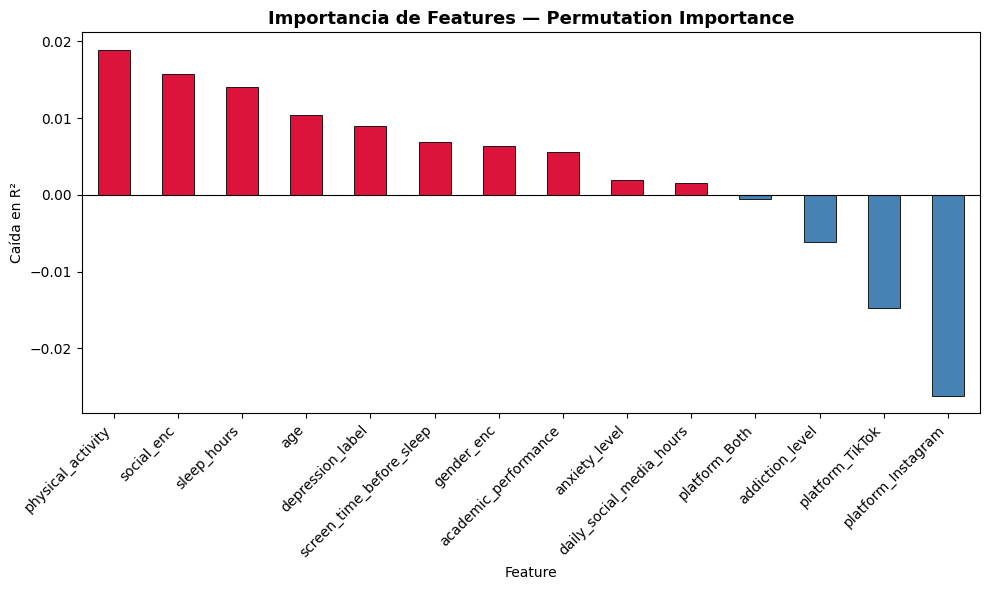

    ✓ Gráfico guardado: permutation_importance_estres.png


In [16]:
# =============================================================================
# 11. IMPORTANCIA DE FEATURES (Permutation Importance)
# =============================================================================
print("\n[11] Calculando Permutation Importance...")

importancias = {}
r2_base = r2_score(y_test, model.predict(X_test_sc, verbose=0).flatten())

for i, col in enumerate(X.columns):
    X_permutado = X_test_sc.copy()
    np.random.seed(42)
    X_permutado[:, i] = np.random.permutation(X_permutado[:, i])
    y_perm_pred  = model.predict(X_permutado, verbose=0).flatten()
    r2_permutado = r2_score(y_test, y_perm_pred)
    importancias[col] = r2_base - r2_permutado   # caída en R²

imp_series = pd.Series(importancias).sort_values(ascending=False)

print("\n📊 Caída en R² al permutar cada variable:")
print(imp_series.round(4))

plt.figure(figsize=(10, 6))
colores = ["crimson" if v > 0 else "steelblue" for v in imp_series]
imp_series.plot(kind="bar", color=colores, edgecolor="k", linewidth=0.6)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Importancia de Features — Permutation Importance", fontsize=13, fontweight="bold")
plt.ylabel("Caída en R²")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("permutation_importance_estres.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráfico guardado: permutation_importance_estres.png")


In [17]:
# =============================================================================
# 12. PREDICCIÓN CON NUEVOS ADOLESCENTES
# =============================================================================
print("\n[12] Predicción con nuevos adolescentes...")

nuevos = pd.DataFrame([
    # Adolescente 1: bajo riesgo (duerme bien, poco uso de redes, activo)
    {
        "age": 15, "gender_enc": 0,
        "daily_social_media_hours": 1.5,
        "platform_Both": 0, "platform_Instagram": 1, "platform_TikTok": 0,
        "sleep_hours": 8.5, "screen_time_before_sleep": 0.5,
        "academic_performance": 3.8, "physical_activity": 2.0,
        "social_enc": 2,  # high
        "anxiety_level": 2, "addiction_level": 2, "depression_label": 0
    },
    # Adolescente 2: alto riesgo (poco sueño, muchas redes, sedentario)
    {
        "age": 17, "gender_enc": 1,
        "daily_social_media_hours": 7.5,
        "platform_Both": 1, "platform_Instagram": 0, "platform_TikTok": 0,
        "sleep_hours": 4.5, "screen_time_before_sleep": 3.0,
        "academic_performance": 2.1, "physical_activity": 0.1,
        "social_enc": 0,  # low
        "anxiety_level": 9, "addiction_level": 9, "depression_label": 1
    },
    # Adolescente 3: perfil promedio
    {
        "age": 16, "gender_enc": 0,
        "daily_social_media_hours": 4.0,
        "platform_Both": 0, "platform_Instagram": 0, "platform_TikTok": 1,
        "sleep_hours": 6.5, "screen_time_before_sleep": 1.5,
        "academic_performance": 3.0, "physical_activity": 1.0,
        "social_enc": 1,  # medium
        "anxiety_level": 5, "addiction_level": 5, "depression_label": 0
    }
])

nuevos_sc   = scaler_X.transform(nuevos)
preds_sc    = model.predict(nuevos_sc, verbose=0)
preds_real  = scaler_y.inverse_transform(preds_sc).ravel()
preds_clip  = np.clip(preds_real, 1, 10)  # mantener en rango 1-10

etiquetas = ["Bajo riesgo", "Alto riesgo", "Perfil promedio"]
print("\n    Resultados de predicción:")
print(f"    {'Adolescente':<20} {'Pred. stress_level':>20}")
print("    " + "-" * 42)
for i, (pred, etq) in enumerate(zip(preds_clip, etiquetas), 1):
    print(f"    {etq:<20} {pred:>15.2f}")



[12] Predicción con nuevos adolescentes...

    Resultados de predicción:
    Adolescente            Pred. stress_level
    ------------------------------------------
    Bajo riesgo                     5.68
    Alto riesgo                     7.33
    Perfil promedio                 5.07


### Predicción con valores personalizados
Modifica el diccionario `custom_obs` con el perfil del adolescente que quieras evaluar.

In [18]:
custom_obs = pd.DataFrame([{
    "age": 14,
    "gender_enc": 1,               # 0=male, 1=female
    "daily_social_media_hours": 5.0,
    "platform_Both": 1,            # 1 si usa ambas plataformas
    "platform_Instagram": 0,
    "platform_TikTok": 0,
    "sleep_hours": 6.0,
    "screen_time_before_sleep": 2.0,
    "academic_performance": 2.8,
    "physical_activity": 0.5,
    "social_enc": 1,               # 0=low, 1=medium, 2=high
    "anxiety_level": 6,
    "addiction_level": 7,
    "depression_label": 0
}])

custom_sc   = scaler_X.transform(custom_obs)
custom_pred = scaler_y.inverse_transform(model.predict(custom_sc, verbose=0)).ravel()
custom_pred_clip = np.clip(custom_pred, 1, 10)

print(f"\nPredicción personalizada:")
print(f"  → Nivel de estrés estimado: {custom_pred_clip[0]:.2f} / 10")



Predicción personalizada:
  → Nivel de estrés estimado: 5.18 / 10


In [19]:
# =============================================================================
# RESUMEN FINAL
# =============================================================================
print("\n" + "=" * 60)
print("   RESUMEN FINAL")
print("=" * 60)
print(f"   Dataset       : Salud Mental Adolescentes ({len(df)} muestras, {X.shape[1]} features)")
print(f"   Épocas reales : {epocas_reales}")
print(f"   RMSE test     : {rmse:.4f}")
print(f"   MAE test      : {mae:.4f}  → ±{mae:.2f} puntos de estrés")
print(f"   R² test       : {r2:.4f}  → {r2*100:.1f}% varianza explicada")
print(f"\n   Archivos generados:")
print(f"   ├── correlacion_estres.png")
print(f"   ├── exploratorio_estres.png")
print(f"   ├── resultados_estres.png")
print(f"   ├── importancia_variables_estres.png")
print(f"   ├── permutation_importance_estres.png")
print(f"   └── mejor_modelo_estres.keras")
print("=" * 60)
print("   PROCESO COMPLETADO EXITOSAMENTE ✓")
print("=" * 60)



   RESUMEN FINAL
   Dataset       : Salud Mental Adolescentes (1200 muestras, 14 features)
   Épocas reales : 37
   RMSE test     : 2.7529
   MAE test      : 2.3452  → ±2.35 puntos de estrés
   R² test       : 0.0165  → 1.6% varianza explicada

   Archivos generados:
   ├── correlacion_estres.png
   ├── exploratorio_estres.png
   ├── resultados_estres.png
   ├── importancia_variables_estres.png
   ├── permutation_importance_estres.png
   └── mejor_modelo_estres.keras
   PROCESO COMPLETADO EXITOSAMENTE ✓
